## Self Attention


MAKING THE INPUT EMBEDDINGS

In [148]:

import bpe as bpe

prompt = "the cat sat on the mat"
ids = bpe.encode(prompt)

In [149]:
ids

[116,
 104,
 101,
 32,
 99,
 97,
 116,
 32,
 115,
 97,
 116,
 32,
 111,
 110,
 32,
 116,
 104,
 101,
 32,
 109,
 97,
 116]

In [150]:
len(ids)

22

In [151]:
# making vector embeddings
import torch

torch_ids = torch.tensor(ids)

vocab_size = 275
embedded_dim = 4

embedded_layer = torch.nn.Embedding(num_embeddings=vocab_size,embedding_dim=embedded_dim)
X = embedded_layer(torch_ids)


In [152]:
X.shape

torch.Size([22, 4])

In [153]:
# positional Embeddings
import numpy as np
def pos_encoding(embedding):
    pos,d = embedding.shape
    pe = torch.zeros(pos,d)
    for j in range(pos):
        for i in (range(d//2)):
            pe[j,2*i] = np.sin(j/10000**(2*i/d))
            pe[j,2*i+1] = np.cos(j/10000**(2*i/d))
    return pe


In [154]:
pe = pos_encoding(X)
pe

tensor([[ 0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0100,  0.9999],
        [ 0.9093, -0.4161,  0.0200,  0.9998],
        [ 0.1411, -0.9900,  0.0300,  0.9996],
        [-0.7568, -0.6536,  0.0400,  0.9992],
        [-0.9589,  0.2837,  0.0500,  0.9988],
        [-0.2794,  0.9602,  0.0600,  0.9982],
        [ 0.6570,  0.7539,  0.0699,  0.9976],
        [ 0.9894, -0.1455,  0.0799,  0.9968],
        [ 0.4121, -0.9111,  0.0899,  0.9960],
        [-0.5440, -0.8391,  0.0998,  0.9950],
        [-1.0000,  0.0044,  0.1098,  0.9940],
        [-0.5366,  0.8439,  0.1197,  0.9928],
        [ 0.4202,  0.9074,  0.1296,  0.9916],
        [ 0.9906,  0.1367,  0.1395,  0.9902],
        [ 0.6503, -0.7597,  0.1494,  0.9888],
        [-0.2879, -0.9577,  0.1593,  0.9872],
        [-0.9614, -0.2752,  0.1692,  0.9856],
        [-0.7510,  0.6603,  0.1790,  0.9838],
        [ 0.1499,  0.9887,  0.1889,  0.9820],
        [ 0.9129,  0.4081,  0.1987,  0.9801],
        [ 0.8367, -0.5477,  0.2085

In [155]:
input_embeddings = X + pe

Pre LLm text conversion Done

In [156]:
input_embeddings.shape

torch.Size([22, 4])

In [157]:
# calculating key , value , query

W_k = torch.rand(4,4,requires_grad=True)
W_v = torch.rand(4,4,requires_grad=True)
W_q = torch.rand(4,4,requires_grad=True)


K = input_embeddings @ W_k
Q = input_embeddings @ W_q
V = input_embeddings @ W_v


In [158]:
value = Q@K.T/np.sqrt(4)
attention_score = torch.nn.functional.softmax(value,dim=-1)@V



In [159]:
output_embeddigs = attention_score+input_embeddings
output_embeddigs

tensor([[ 4.5706,  4.5716,  1.5141,  5.7076],
        [ 5.2367,  3.7103,  3.1054,  7.3129],
        [ 1.3302,  0.1447, -0.5258,  4.7368],
        [-0.6507, -0.8597,  0.3736, -2.0502],
        [ 0.4115, -1.0449, -0.4507,  1.1940],
        [ 0.7150,  2.2283,  2.3993,  2.3415],
        [ 4.2405,  4.4861,  1.5476,  5.6309],
        [ 1.9214,  3.2614,  2.1215,  2.0159],
        [ 3.8545,  3.9120,  2.3241,  7.2288],
        [ 2.1945,  1.2253,  2.5944,  2.7089],
        [ 2.6591,  1.4701,  0.9273,  3.8077],
        [-1.8301,  0.0202,  0.3517, -2.3145],
        [ 3.3971,  3.3957,  1.5611,  3.5752],
        [ 2.0387,  1.0945,  0.2216,  5.2764],
        [ 2.0373,  2.4427,  2.0861,  1.7218],
        [ 4.8939,  2.5366,  1.5205,  5.2869],
        [ 3.9224,  2.0531,  3.1646,  7.0366],
        [-1.4825, -1.0808, -1.5121,  2.1305],
        [-0.8945,  1.5049,  1.0754, -0.8086],
        [ 4.0082,  4.3506,  3.5525,  5.8299],
        [ 3.7840,  3.5865,  3.2646,  4.2645],
        [ 5.2848,  2.9262,  1.6733

In [160]:
output_embeddigs = torch.nn.functional.rms_norm(output_embeddigs,normalized_shape=(output_embeddigs.shape[-1],))
output_embeddigs


tensor([[ 1.0440,  1.0443,  0.3459,  1.3038],
        [ 1.0255,  0.7266,  0.6081,  1.4320],
        [ 0.5374,  0.0585, -0.2125,  1.9138],
        [-0.5547, -0.7328,  0.3185, -1.7475],
        [ 0.4841, -1.2293, -0.5303,  1.4048],
        [ 0.3497,  1.0900,  1.1737,  1.1454],
        [ 0.9981,  1.0559,  0.3642,  1.3253],
        [ 0.8031,  1.3633,  0.8868,  0.8427],
        [ 0.8226,  0.8349,  0.4960,  1.5428],
        [ 0.9721,  0.5428,  1.1492,  1.1999],
        [ 1.0725,  0.5929,  0.3740,  1.5357],
        [-1.2317,  0.0136,  0.2367, -1.5578],
        [ 1.0980,  1.0975,  0.5046,  1.1555],
        [ 0.7072,  0.3797,  0.0769,  1.8303],
        [ 0.9759,  1.1701,  0.9992,  0.8247],
        [ 1.2568,  0.6515,  0.3905,  1.3578],
        [ 0.8819,  0.4616,  0.7115,  1.5821],
        [-0.9288, -0.6771, -0.9473,  1.3347],
        [-0.8102,  1.3632,  0.9741, -0.7324],
        [ 0.8874,  0.9632,  0.7865,  1.2907],
        [ 1.0111,  0.9583,  0.8723,  1.1395],
        [ 1.2631,  0.6994,  0.3999

In [161]:
def init_w():
    w1 = torch.rand(4,16)
    w2 = torch.rand(16,4)
    b1= torch.rand(16,)
    b2 = torch.rand(4,)

    return w1,w2,b1,b2

In [162]:
w1,w2,b1,b2 = init_w()

In [163]:
def feedforward(output_embeddigs,w1,w2,b1,b2):


    z1 = torch.nn.functional.relu(output_embeddigs @ w1 + b1)
    return z1@w2+b2

In [164]:
ff_out = feedforward(output_embeddigs,w1,w2,b1,b2)
output = ff_out + output_embeddigs


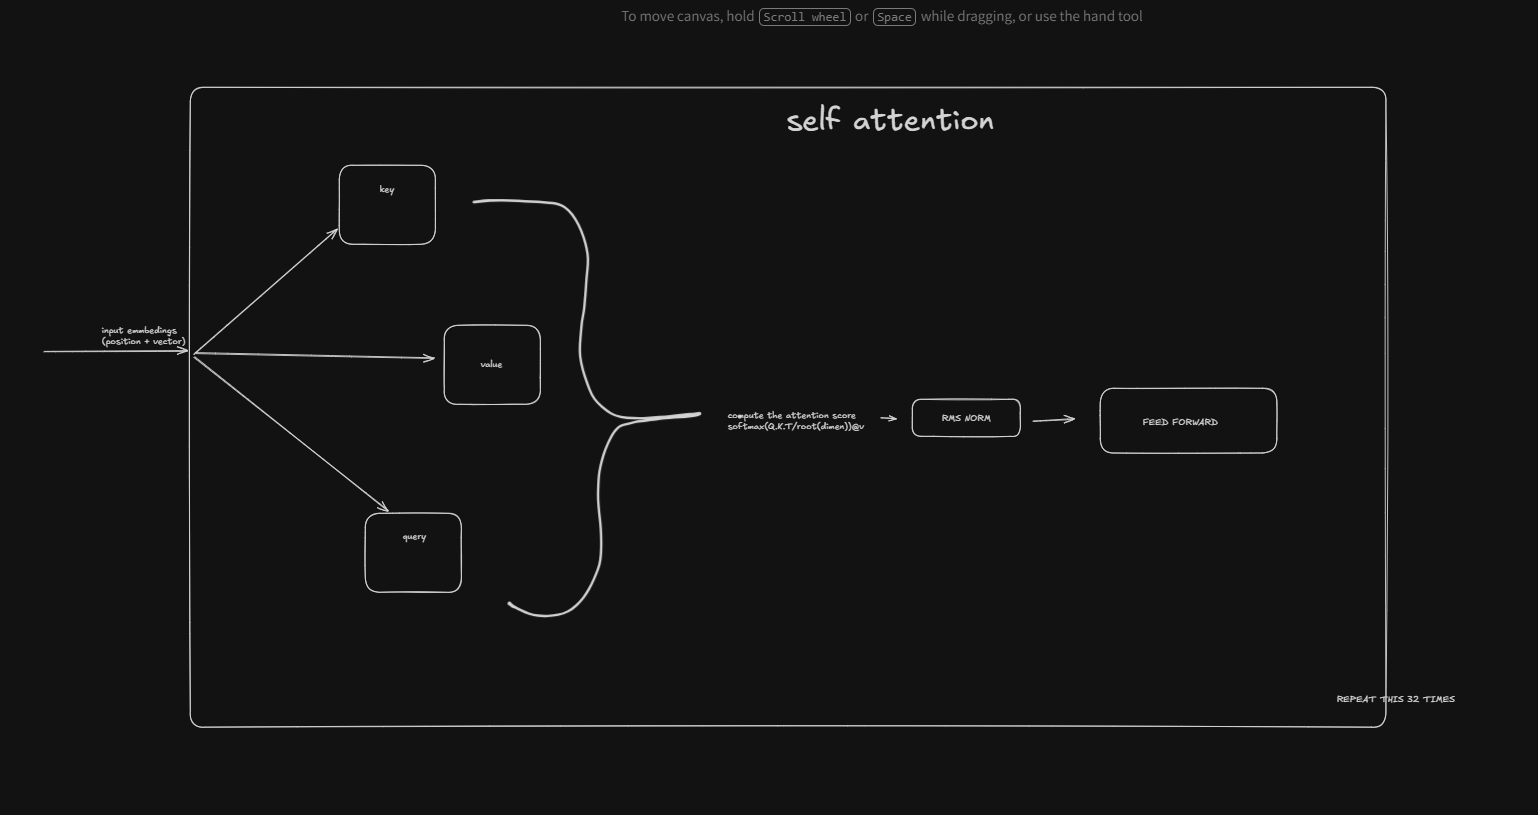

In [165]:
# loss = torch.nn.functional.cross_entropy(output)
for i in range(32):
    Q = output@W_q
    K = output@W_k
    V = output@W_v
    value = Q@K.T/np.sqrt(4)
    attention_score = torch.nn.functional.softmax(value,dim=-1)@V
    output_embeddigs = output+attention_score
    output_embeddigs = torch.nn.functional.rms_norm(output_embeddigs,normalized_shape=(output_embeddigs.shape[-1],))
    ff_out = feedforward(output_embeddigs,w1,w2,b1,b2)
    output = ff_out + output_embeddigs
    loss = output.sum()
    loss.backward(retain_graph=True)  # needed because output feeds into next iteration



    print(f"Layer {i+1} loss: {loss.item():.4f}")


Layer 1 loss: 1680.7582
Layer 2 loss: 1689.6248
Layer 3 loss: 1690.0365
Layer 4 loss: 1690.0507
Layer 5 loss: 1690.0513
Layer 6 loss: 1690.0510
Layer 7 loss: 1690.0510
Layer 8 loss: 1690.0510
Layer 9 loss: 1690.0510
Layer 10 loss: 1690.0510
Layer 11 loss: 1690.0513
Layer 12 loss: 1690.0513
Layer 13 loss: 1690.0513
Layer 14 loss: 1690.0513
Layer 15 loss: 1690.0513
Layer 16 loss: 1690.0513
Layer 17 loss: 1690.0513
Layer 18 loss: 1690.0513
Layer 19 loss: 1690.0513
Layer 20 loss: 1690.0513
Layer 21 loss: 1690.0513
Layer 22 loss: 1690.0513
Layer 23 loss: 1690.0513
Layer 24 loss: 1690.0513
Layer 25 loss: 1690.0513
Layer 26 loss: 1690.0513
Layer 27 loss: 1690.0513
Layer 28 loss: 1690.0513
Layer 29 loss: 1690.0513
Layer 30 loss: 1690.0513
Layer 31 loss: 1690.0513
Layer 32 loss: 1690.0513


In [166]:
output

tensor([[24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900, 18.0218],
        [24.8825, 18.4262, 15.4900

In [167]:
Q = output@W_q
K = output@W_k
V = output@W_v
value = Q@K.T/np.sqrt(4)
attention_score = torch.nn.functional.softmax(value,dim=-1)@V
output_embeddigs = output+attention_score
output_embeddigs = torch.nn.functional.rms_norm(output_embeddigs,normalized_shape=(output_embeddigs.shape[-1],))
ff_out = feedforward(output_embeddigs,w1,w2,b1,b2)
output = ff_out + output_embeddigs
